In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from numpy import save
import scipy
from scipy import stats
from pathlib import Path
import seaborn as sns
from matplotlib import cm
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as plticker
from scipy.stats import gaussian_kde
from matplotlib.colors import TwoSlopeNorm
from scipy.ndimage import gaussian_filter
import matplotlib.colors as mcolors
import matplotlib.collections as mcoll
import os
from scipy.interpolate import UnivariateSpline

In [3]:
## look at individual stimui responses 

def load_dataframes_from_subfolders(parent_path):
    dataframes = []
    for subfolder in parent_path.iterdir():
        if subfolder.is_dir():
            for file_path in subfolder.glob("*.csv"):
                dataframes.append(pd.read_csv(file_path))
    return dataframes

# Define the parent directory
parent_dir = Path(r"/Volumes/LaCie/free_swimming/7dpf_TRex/adenosine_2.5mM")
exp_name = parent_dir.name
color = 'plum'
stim = 'Ade'

# Load dataframes from "stim" and "control" subfolders
stim_fish = load_dataframes_from_subfolders(parent_dir / "stim")
control_fish = load_dataframes_from_subfolders(parent_dir / "base")

## filter the data for average analysis 

In [4]:
# remove fish not tracked for the majority of the video and fish that don't swim much 
def total_distance_travelled(df):
    dx = df['x'][df['mask']].diff()
    dy = df['y'][df['mask']].diff()
    return np.sqrt(dx**2 + dy**2).sum()

def is_fish_significantly_moving(df, movement_threshold, tracking_threshold):
    total_frames = len(df)
    tracked_frames = len(df[df["mask"]])
    vx = df['acceleration'][df['mask']]
    
    tracking_percentage = (tracked_frames / total_frames) * 100

    if tracking_percentage < tracking_threshold:
        return False
    
    valid_data = df[df["mask"]]
    return total_distance_travelled(valid_data) > movement_threshold
    
movement_threshold = 60
tracking_threshold = 90


filtered_stim = [fish_df for fish_df in stim_fish if is_fish_significantly_moving(fish_df, movement_threshold, tracking_threshold)]
filtered_control = [fish_df for fish_df in control_fish if is_fish_significantly_moving(fish_df, movement_threshold, tracking_threshold)]                        


In [5]:
len(stim_fish),len(filtered_stim), len(control_fish), len(filtered_control)

(164, 146, 166, 140)

## Create subtracted heatmaps

In [6]:
def get_all_x_y(list_dfs):
    """
    Extracts the second half of x and y coordinates from a list of dataframes
    where the mask condition is True.

    :param list_dfs: List of pandas DataFrames with columns 'x', 'y', and 'mask'.
    :return: Two lists containing all x and y coordinates.
    """
    all_x = []
    all_y = []

    for df in list_dfs:
        half_len = len(df) // 2
        filtered_df = df[half_len:]
        all_x.extend(filtered_df.loc[filtered_df['mask'], 'x'])
        all_y.extend(filtered_df.loc[filtered_df['mask'], 'y'])
    
    return all_x, all_y

def normalize_to_range(values, new_min=-1, new_max=1):
    """
    Normalize a list of values to a specified range.

    :param values: List of numbers to be normalized.
    :param new_min: Minimum value of the new range.
    :param new_max: Maximum value of the new range.
    :return: List of normalized numbers.
    """
    old_min = min(values)
    old_max = max(values)

    # Min-max normalization to 0-1 range
    normalized_0_1 = [(x - old_min) / (old_max - old_min) for x in values]

    # Scale to new range (new_min to new_max)
    normalized = [new_min + (x * (new_max - new_min)) for x in normalized_0_1]

    return normalized

def normalize_heatmap(heatmap):
    """
    Normalize a heatmap so that the sum of all density values equals 1.

    :param heatmap: 2D numpy array representing the heatmap.
    :return: Normalized heatmap.
    """
    return heatmap / np.sum(heatmap)

def create_difference_heatmap(title, stim_df_list, control_df_list, arena_size=(2, 1), bins=(11, 6), sigma=1):
    """
    Create a difference heatmap between stimulus and control conditions from a list of dataframes,
    with optional Gaussian smoothing.

    :param title: Title of the plot.
    :param stim_df_list: List of dataframes for the stimulus condition.
    :param control_df_list: List of dataframes for the control condition.
    :param arena_size: Size of the arena (width, height) in normalized units.
    :param bins: Number of bins for the heatmap in each dimension (x_bins, y_bins).
    :param sigma: Standard deviation for Gaussian smoothing.
    """
    # Step 1: Calculate heatmap for stimulus condition
    stim_x_positions, stim_y_positions = get_all_x_y(stim_df_list)
    stim_normalised_x = normalize_to_range(stim_x_positions, new_min=0, new_max=arena_size[0])
    stim_normalised_y = normalize_to_range(stim_y_positions, new_min=0, new_max=arena_size[1])
    
    stim_heatmap, xedges, yedges = np.histogram2d(stim_normalised_x, stim_normalised_y, bins=bins, range=[[0, arena_size[0]], [0, arena_size[1]]])
    
    # Apply Gaussian smoothing to the stimulus heatmap
    stim_heatmap = gaussian_filter(normalize_heatmap(stim_heatmap), sigma=sigma)

    # Step 2: Calculate heatmap for control condition
    control_x_positions, control_y_positions = get_all_x_y(control_df_list)
    control_normalised_x = normalize_to_range(control_x_positions, new_min=0, new_max=arena_size[0])
    control_normalised_y = normalize_to_range(control_y_positions, new_min=0, new_max=arena_size[1])
    
    control_heatmap, _, _ = np.histogram2d(control_normalised_x, control_normalised_y, bins=bins, range=[[0, arena_size[0]], [0, arena_size[1]]])
    
    # Apply Gaussian smoothing to the control heatmap
    control_heatmap = gaussian_filter(normalize_heatmap(control_heatmap), sigma=sigma)

    # Step 3: Calculate the difference heatmap (stimulus - control)
    difference_heatmap = stim_heatmap - control_heatmap

    # Step 4: Plot the difference heatmap
    fig = plt.figure(figsize=(6, 3))
    ax_main = fig.add_subplot(111)
    ax_main.set_title(title, fontsize=22, weight='bold', x=0.1, y=1.15)  # Set title on the main axis
    
    # Define the colormap normalization
    norm = TwoSlopeNorm(vmin=-0.02, vcenter=0, vmax=0.02)
    # Plotting the main heatmap
    cax = ax_main.imshow(difference_heatmap.T, extent=[0, arena_size[0], 0, arena_size[1]], 
                         origin='lower', aspect='auto', cmap='coolwarm', norm=norm, interpolation='nearest')
    ax_main.set_xlabel(r"$X_{\mathrm{norm}}$", fontsize=26)
    ax_main.set_ylabel(r"$Y_{\mathrm{norm}}$", fontsize=26)
    ax_main.tick_params(axis='both', labelsize=26)
    # ax_main.axvline(x=1, color='black', linestyle='dashed', alpha=0.5)

    # Step 5: Calculate and plot the difference histograms
    stim_x_hist, _ = np.histogram(stim_normalised_x, bins=xedges, range=[0, arena_size[0]])
    control_x_hist, _ = np.histogram(control_normalised_x, bins=xedges, range=[0, arena_size[0]])
    diff_x_hist = stim_x_hist - control_x_hist

    stim_y_hist, _ = np.histogram(stim_normalised_y, bins=yedges, range=[0, arena_size[1]])
    control_y_hist, _ = np.histogram(control_normalised_y, bins=yedges, range=[0, arena_size[1]])
    diff_y_hist = stim_y_hist - control_y_hist
    
    # Set bar heights to match the heatmap grid
    bbox = ax_main.get_position()
    ax_x_hist = fig.add_axes([bbox.x0, bbox.y1 + 0.01, bbox.width, 0.09])  # Adjust y1 and height as needed for x-histogram
    ax_y_hist = fig.add_axes([bbox.x1 + 0.01, bbox.y0, 0.06, bbox.height])  # Adjust x1 and width as needed for y-histogram
    
    ax_x_hist.margins(x=0)
    ax_y_hist.margins(y=0)
    
    ax_x_hist.axis('off')
    ax_y_hist.axis('off')
    
    # Marginal histograms representing the difference
    ax_x_hist.bar(range(len(diff_x_hist)), diff_x_hist,  width=1, color='darkblue', alpha=0.6)
    ax_y_hist.barh(range(len(diff_y_hist)), diff_y_hist, height=1, color='darkblue', alpha=0.6)

    # Add color bar
    ax_colorbar = fig.add_axes([bbox.x1 + 0.1, bbox.y0, 0.02, bbox.height])
    colorbar = plt.colorbar(cax, cax=ax_colorbar)
    colorbar.ax.tick_params(labelsize=26)
    colorbar.set_label(r"Δ Density", fontsize=26, labelpad=10)
    colorbar.set_ticks([-0.02, 0, 0.02])  # Optional: set ticks explicitly

    
    # plt.savefig(f"/Users/bethanjenkins/Documents/valence_paper_code/FiNA/figures/4-7dpf_new_{title}_heatmap.svg", format="svg", dpi=300, bbox_inches="tight")
    plt.show()


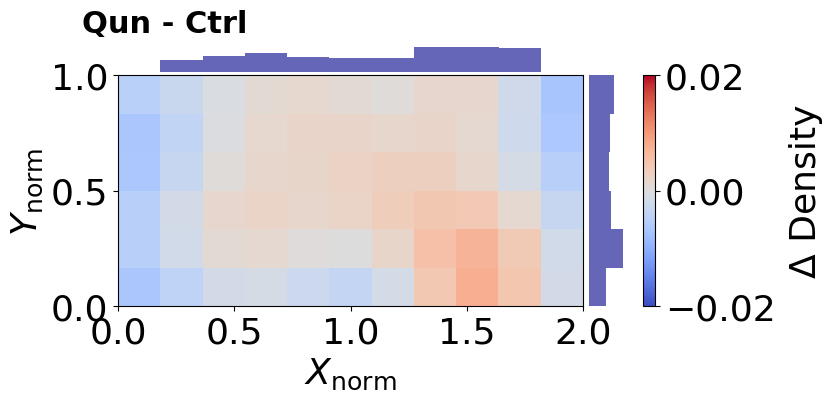

In [7]:
create_difference_heatmap('Qun - Ctrl', filtered_stim, filtered_control)

## plot Single fish examples

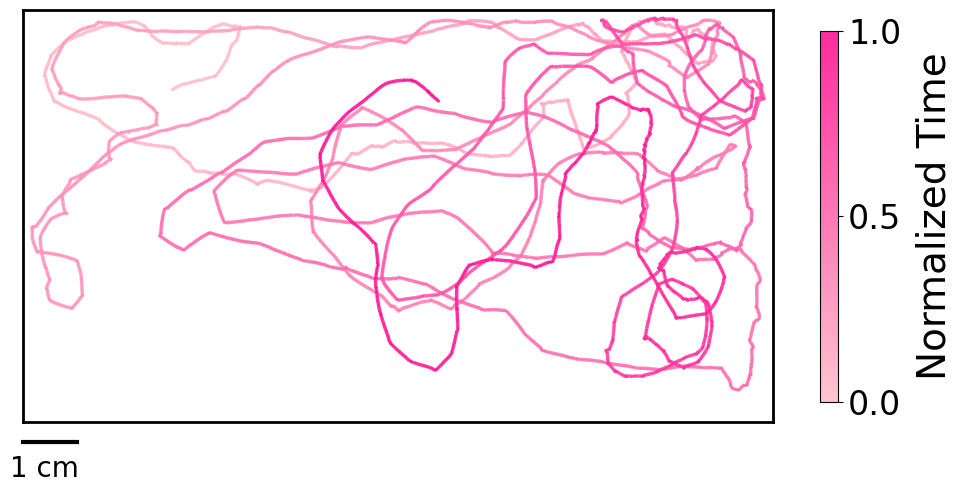

In [5]:
fish = filtered_stim[59]   ## quinine fish 59  food extract 57? 

# Ensure missing values are explicitly represented as NaN
fish['x'] = fish['x'].replace([np.inf, -np.inf], np.nan)
fish['y'] = fish['y'].replace([np.inf, -np.inf], np.nan)
fish['time'] = fish['time'].replace([np.inf, -np.inf], np.nan)

# Interpolate missing values in x, y, and time
fish['x'] = fish['x'].interpolate(method='linear', limit_direction='both')
fish['y'] = fish['y'].interpolate(method='linear', limit_direction='both')
fish['time'] = fish['time'].interpolate(method='linear', limit_direction='both')

# Normalize time values for proper color mapping
time_normalized = (fish['time'] - fish['time'].min()) / (fish['time'].max() - fish['time'].min())

# Define custom colormap from light pink to dark magenta
cmap = mcolors.LinearSegmentedColormap.from_list("pink_magenta", ["pink", "deeppink"])
# cmap = mcolors.LinearSegmentedColormap.from_list("green_lime", ["lightgreen", "darkgreen"])

# Create figure
fig, ax = plt.subplots(figsize=(10, 5))

# Prepare segments for colored line
points = np.array([fish['x'], fish['y']]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Create a LineCollection for time-based color mapping with thicker lines
norm = plt.Normalize(time_normalized.min(), time_normalized.max())
lc = mcoll.LineCollection(segments, cmap=cmap, norm=norm, linewidth=2.5, alpha=0.9)  # Thicker line
lc.set_array(time_normalized)  # Set colors based on normalized time

# Add the colored trajectory line
ax.add_collection(lc)

# Overlay points for additional size
ax.scatter(fish['x'], fish['y'], c=time_normalized, cmap=cmap, s=1, alpha=0.8, edgecolors='none')  # Increase `s` for larger points

# Adjust plot limits
ax.set_xlim(0.1, 14)
ax.set_ylim(0.6, 6.8)
ax.set_yticks([])
ax.set_xticks([])

# Increase axis line width
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)

# Add scale bar (1 cm)
ax.text(0.5, -0.1, "1 cm", ha='center', va='center', fontsize=20, color='black')
ax.plot([0.1, 1.1], [0.3, 0.3], color='black', linewidth=3, clip_on=False)

# Add colorbar
cbar = plt.colorbar(lc, ax=ax, shrink=0.9)
cbar.set_label(r"Normalized Time", fontsize=28, labelpad=10)
cbar.ax.tick_params(labelsize=24)  # Increase colorbar number size
cbar.set_ticks([0, 0.5, 1.0]) 

# Show plot
plt.tight_layout()
# plt.savefig(f"/Users/bethanjenkins/Documents/valence_paper_code/FiNA/svg_figures/7dpf_trajectory_qui_example.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()